In [3]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import cuda


In [4]:
img = plt.imread("photo.jpg")
h, w, _ = img.shape
pixelCount = h * w
flat = img.reshape(pixelCount, 3)
print(img.shape, pixelCount)


(651, 471, 3) 306621


In [5]:
start = time.time()

grayCPU = np.zeros((pixelCount, 3), np.uint8)
for i in range(pixelCount):
    g = (int(flat[i, 0]) + int(flat[i, 1]) + int(flat[i, 2])) // 3
    grayCPU[i, 0] = g
    grayCPU[i, 1] = g
    grayCPU[i, 2] = g

cpuTime = time.time() - start
print("CPU time:", cpuTime, "s")


CPU time: 0.4314408302307129 s


In [6]:
@cuda.jit
def grayscale(src, dst):
    tidx = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    if tidx < src.shape[0]:
        g = np.uint8((src[tidx, 0] + src[tidx, 1] + src[tidx, 2]) / 3)
        dst[tidx, 0] = g
        dst[tidx, 1] = g
        dst[tidx, 2] = g


In [7]:
@cuda.jit
def grayscale2d(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y
    if y < src.shape[0] and x < src.shape[1]:
        g = np.uint8((src[y, x, 0] + src[y, x, 1] + src[y, x, 2]) / 3)
        dst[y, x, 0] = g
        dst[y, x, 1] = g
        dst[y, x, 2] = g


In [8]:
devSrc1D = cuda.to_device(flat)
devDst1D = cuda.device_array((pixelCount, 3), np.uint8)

devSrc2D = cuda.to_device(img)
devDst2D = cuda.device_array((h, w, 3), np.uint8)


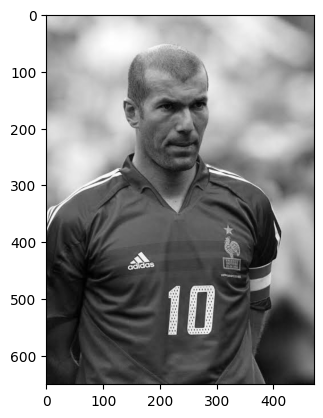

Same as CPU: True


In [9]:
blockSize = (16, 16)
gridSize = ((w + 15) // 16, (h + 15) // 16)

grayscale2d[gridSize, blockSize](devSrc2D, devDst2D)
cuda.synchronize()

gray2D = devDst2D.copy_to_host()
plt.imshow(gray2D)
plt.show()
plt.imsave("gray_gpu_2d.png", gray2D)

print("Same as CPU:", np.array_equal(gray2D.reshape(pixelCount, 3), grayCPU))


In [10]:
def measure(kernel, grid, block, src, dst):
    kernel[grid, block](src, dst)
    cuda.synchronize()
    start = time.time()
    for r in range(100):
        kernel[grid, block](src, dst)
    cuda.synchronize()
    return (time.time() - start) / 100


8 x 8 = 64 threads | 1D: 7.916450500488282e-05 s | 2D: 8.085489273071289e-05 s
16 x 8 = 128 threads | 1D: 7.826805114746093e-05 s | 2D: 8.22305679321289e-05 s
16 x 16 = 256 threads | 1D: 7.880210876464843e-05 s | 2D: 8.085012435913086e-05 s
32 x 16 = 512 threads | 1D: 7.839202880859375e-05 s | 2D: 8.314132690429688e-05 s
32 x 32 = 1024 threads | 1D: 8.791685104370117e-05 s | 2D: 9.003162384033203e-05 s


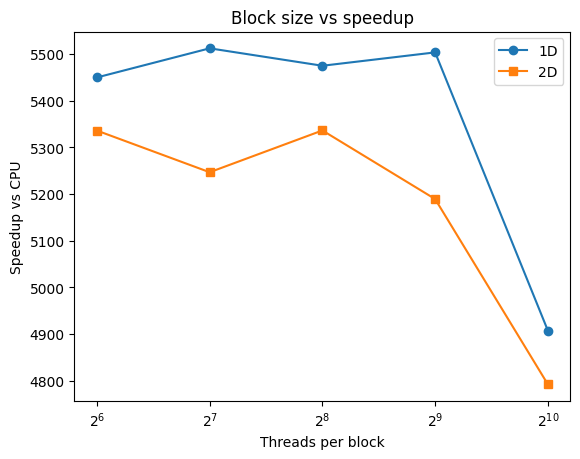

In [11]:
blocks2D = [(8, 8), (16, 8), (16, 16), (32, 16), (32, 32)]
threads = []
speedup1D = []
speedup2D = []

for bx, by in blocks2D:
    n = bx * by

    grid2D = ((w + bx - 1) // bx, (h + by - 1) // by)
    t2 = measure(grayscale2d, grid2D, (bx, by), devSrc2D, devDst2D)

    grid1D = (pixelCount + n - 1) // n
    t1 = measure(grayscale, grid1D, n, devSrc1D, devDst1D)

    threads.append(n)
    speedup1D.append(cpuTime / t1)
    speedup2D.append(cpuTime / t2)
    print(bx, "x", by, "=", n, "threads | 1D:", t1, "s | 2D:", t2, "s")

plt.plot(threads, speedup1D, marker="o", label="1D")
plt.plot(threads, speedup2D, marker="s", label="2D")
plt.xscale("log", base=2)
plt.xlabel("Threads per block")
plt.ylabel("Speedup vs CPU")
plt.title("Block size vs speedup")
plt.legend()
plt.savefig("blocksize_vs_speedup.png")
plt.show()
